Train images: 18257
Classes: ['EarlyBlight', 'Healthy', 'LateBlight']
Validation images: 407
Test images: 408


I0000 00:00:1777780826.321991      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20


I0000 00:00:1777780835.348045     131 service.cc:152] XLA service 0x7d15bc003b20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777780835.348107     131 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777780836.673510     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777780847.729416     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


570/570 ━━━━━━━━━━━━━━━━━━━━ 226s 351ms/step - accuracy: 0.8341 - loss: 0.4041 - val_accuracy: 0.9349 - val_loss: 0.1789
Epoch 2/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 103s 151ms/step - accuracy: 0.9459 - loss: 0.1646 - val_accuracy: 0.9557 - val_loss: 0.1298
Epoch 3/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 87s 152ms/step - accuracy: 0.9563 - loss: 0.1246 - val_accuracy: 0.9609 - val_loss: 0.1140
Epoch 4/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 100s 176ms/step - accuracy: 0.9640 - loss: 0.1036 - val_accuracy: 0.9653 - val_loss: 0.0812
Epoch 5/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 83s 146ms/step - accuracy: 0.9732 - loss: 0.0825 - val_accuracy: 0.9787 - val_loss: 0.0705
Epoch 6/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 82s 144ms/step - accuracy: 0.9756 - loss: 0.0729 - val_accuracy: 0.9707 - val_loss: 0.0906
Epoch 7/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 79s 139ms/step - accuracy: 0.9812 - loss: 0.0581 - val_accuracy: 0.9813 - val_loss: 0.0537
Epoch 8/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 80s 140ms/step - accuracy: 0.9805 - loss: 0.0595 - 

✅ Model saved at: /kaggle/working/final_model.h5
📦 Zipped model saved at: /kaggle/working/final_model.zip

✅ Test Accuracy: 0.9902

📊 Classification Report:
              precision    recall  f1-score   support

 EarlyBlight     1.0000    0.9877    0.9938       163
     Healthy     0.9714    1.0000    0.9855       102
  LateBlight     0.9930    0.9860    0.9895       143

    accuracy                         0.9902       408
   macro avg     0.9881    0.9912    0.9896       408
weighted avg     0.9904    0.9902    0.9902       408



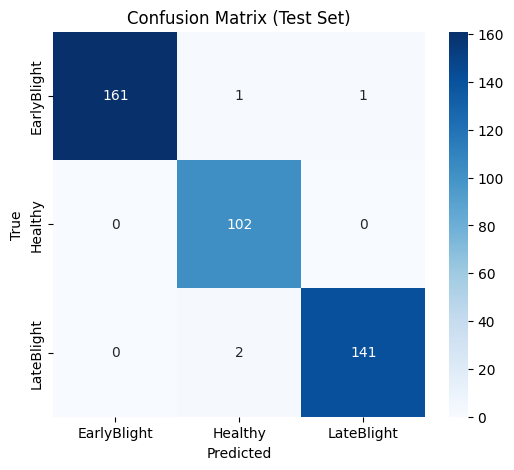

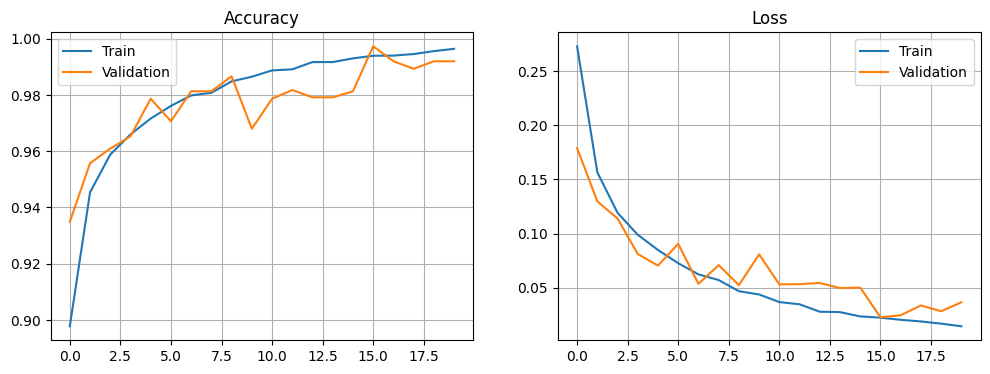

In [2]:
# ============================================================
# TRAIN–VALIDATION–TEST PIPELINE (FOLDER-BASED)
# PRETRAINED XCEPTION | IMAGE SIZE: 256×256 | CLASSES: 3
# ============================================================

# ---------------- IMPORTS ----------------
import os, cv2, zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/pld-foldds/PLD_FOLDDATASET"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ---------------- LOAD TRAIN DATA ----------------
train_paths, train_labels = [], []

class_names = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(class_names)

for idx, cls in enumerate(class_names):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for f in os.listdir(cls_dir):
        train_paths.append(os.path.join(cls_dir, f))
        train_labels.append(idx)

X_train = np.array(train_paths)
y_train = np.array(train_labels)

print("Train images:", len(X_train))
print("Classes:", class_names)

# ---------------- LOAD VALIDATION DATA ----------------
val_paths, val_labels = [], []

for idx, cls in enumerate(class_names):
    cls_dir = os.path.join(VAL_DIR, cls)
    for f in os.listdir(cls_dir):
        val_paths.append(os.path.join(cls_dir, f))
        val_labels.append(idx)

X_val = np.array(val_paths)
y_val = np.array(val_labels)

print("Validation images:", len(X_val))

# ---------------- LOAD TEST DATA ----------------
test_paths, test_labels = [], []

for idx, cls in enumerate(class_names):
    cls_dir = os.path.join(TEST_DIR, cls)
    for f in os.listdir(cls_dir):
        test_paths.append(os.path.join(cls_dir, f))
        test_labels.append(idx)

X_test = np.array(test_paths)
y_test = np.array(test_labels)

print("Test images:", len(X_test))

# ---------------- DATA GENERATOR ----------------
def data_generator(paths, labels, augment=False):
    while True:
        idxs = np.arange(len(paths))
        np.random.shuffle(idxs)

        for i in range(0, len(paths), BATCH_SIZE):
            batch_idx = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch_idx:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)

                img = preprocess_input(img.astype("float32"))
                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, NUM_CLASSES)

# ---------------- MODEL ----------------
def create_model():
    base = Xception(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs=base.input, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ---------------- TRAINING ----------------
model = create_model()

history = model.fit(
    data_generator(X_train, y_train, augment=True),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_data=data_generator(X_val, y_val),
    validation_steps=len(X_val)//BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

# ================= SAVE MODEL =================
SAVE_PATH = "/kaggle/working/final_model.h5"
model.save(SAVE_PATH)
print(f"✅ Model saved at: {SAVE_PATH}")

# ================= ZIP MODEL =================
ZIP_PATH = "/kaggle/working/final_model.zip"

with zipfile.ZipFile(ZIP_PATH, 'w') as zipf:
    zipf.write(SAVE_PATH, arcname="final_model.h5")

print(f"📦 Zipped model saved at: {ZIP_PATH}")

# ---------------- TESTING ----------------
y_true, y_pred = [], []
test_gen = data_generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(test_gen)
    preds = model.predict(imgs, verbose=0)
    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

test_acc = np.mean(y_true == y_pred)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# ---------------- CLASSIFICATION REPORT ----------------
print("\n📊 Classification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4
))

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---------------- TRAINING CURVES ----------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.show()

Training Classes: ['EarlyBlight', 'Healthy', 'LateBlight']
Total Test Images: 2152

✅ Test Accuracy: 0.4786

📊 Classification Report on PlantVillage on Xception Model:
              precision    recall  f1-score   support

 EarlyBlight     0.9352    0.1010    0.1823      1000
     Healthy     0.3741    0.9868    0.5425       152
  LateBlight     0.4741    0.7790    0.5895      1000

    accuracy                         0.4786      2152
   macro avg     0.5945    0.6223    0.4381      2152
weighted avg     0.6813    0.4786    0.3970      2152



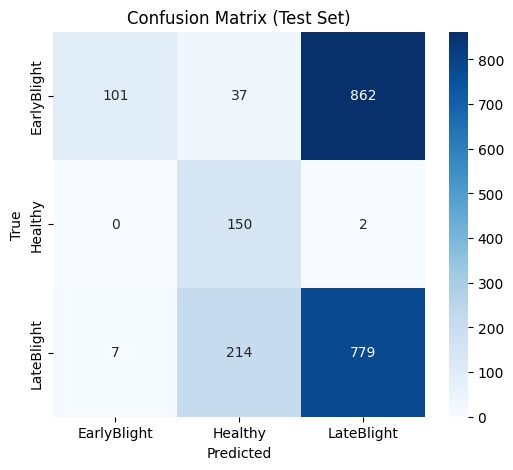

In [3]:
# ============================================================
# TESTING PIPELINE (WITH CLASS NAME MAPPING)
# ============================================================

# ---------------- IMPORTS ----------------
import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/potatoleafplantvillage/PlantVillageExtended"
TEST_DIR = os.path.join(DATASET_DIR, "Test")

IMG_SIZE = 256
BATCH_SIZE = 32

# ---------------- LOAD MODEL ----------------
MODEL_PATH = "/kaggle/working/final_model.h5"   # update path
model = load_model(MODEL_PATH)

# ---------------- FIX CLASS ORDER (SAME AS TRAINING) ----------------
class_names = ["EarlyBlight", "Healthy", "LateBlight"]
NUM_CLASSES = len(class_names)

print("Training Classes:", class_names)

# ---------------- DEFINE CLASS MAPPING ----------------
# 👉 Change keys based on your TEST folder names
class_mapping = {
    "Early_Blight": "EarlyBlight",
    "Healthy": "Healthy",
    "Late_Blight": "LateBlight"
}

# ---------------- LOAD TEST DATA ----------------
test_paths, test_labels = [], []

for test_cls in os.listdir(TEST_DIR):

    mapped_cls = class_mapping.get(test_cls)

    if mapped_cls is None:
        print(f"⚠️ Skipping unknown class: {test_cls}")
        continue

    label = class_names.index(mapped_cls)
    cls_dir = os.path.join(TEST_DIR, test_cls)

    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.png','.jpg','.jpeg')):
            test_paths.append(os.path.join(cls_dir, f))
            test_labels.append(label)

X_test = np.array(test_paths)
y_test = np.array(test_labels)

print("Total Test Images:", len(X_test))

# ---------------- TEST GENERATOR (NO AUGMENTATION) ----------------
def test_generator(paths, labels):
    while True:
        for i in range(0, len(paths), BATCH_SIZE):
            imgs, labs = [], []

            for j in range(i, min(i+BATCH_SIZE, len(paths))):
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                img = preprocess_input(img.astype("float32"))
                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, NUM_CLASSES)

# ---------------- RUN TESTING ----------------
y_true, y_pred = [], []

gen = test_generator(X_test, y_test)
steps = len(X_test) // BATCH_SIZE + 1

for _ in range(steps):
    imgs, labs = next(gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Trim extra
y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ---------------- METRICS ----------------
accuracy = np.mean(y_true == y_pred)

print(f"\n✅ Test Accuracy: {accuracy:.4f}")

print("\n📊 Classification Report on PlantVillage on Xception Model:")
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4
))

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [4]:
# ============================================================
# BAYESIAN OPTIMIZED XCEPTION PIPELINE
# ============================================================

import os, cv2, zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 👉 KERAS TUNER
import keras_tuner as kt

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/pld-foldds/PLD_FOLDDATASET"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10   # keep small during tuning

# ---------------- LOAD DATA ----------------
def load_data(folder):
    paths, labels = [], []
    classes = sorted(os.listdir(folder))

    for idx, cls in enumerate(classes):
        for f in os.listdir(os.path.join(folder, cls)):
            paths.append(os.path.join(folder, cls, f))
            labels.append(idx)

    return np.array(paths), np.array(labels), classes

X_train, y_train, class_names = load_data(TRAIN_DIR)
X_val, y_val, _ = load_data(VAL_DIR)
X_test, y_test, _ = load_data(TEST_DIR)

NUM_CLASSES = len(class_names)

# ---------------- GENERATOR ----------------
def generator(paths, labels):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = preprocess_input(img.astype("float32"))

                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, NUM_CLASSES)

# ---------------- MODEL BUILDER ----------------
def build_model(hp):

    base = Xception(weights="imagenet", include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))

    # Tune fine-tuning
    fine_tune = hp.Boolean("fine_tune")
    base.trainable = fine_tune

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)

    # Tune dense size
    dense_units = hp.Int("dense_units", 256, 1024, step=256)
    x = layers.Dense(dense_units, activation="relu")(x)

    # Tune dropout
    dropout = hp.Float("dropout", 0.3, 0.7, step=0.1)
    x = layers.Dropout(dropout)(x)

    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs=base.input, outputs=out)

    # Tune learning rate
    lr = hp.Choice("lr", [1e-3, 1e-4, 1e-5])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ---------------- BAYESIAN TUNER ----------------
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=5,   # keep small for Kaggle
    directory="/kaggle/working/tuner",
    project_name="pld_xception"
)

# ---------------- RUN SEARCH ----------------
tuner.search(
    generator(X_train, y_train),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_data=generator(X_val, y_val),
    validation_steps=len(X_val)//BATCH_SIZE,
    epochs=EPOCHS
)

# ---------------- BEST MODEL ----------------
best_model = tuner.get_best_models(1)[0]

print("✅ Best hyperparameters found")

# ---------------- FINAL TRAINING ----------------
history = best_model.fit(
    generator(X_train, y_train),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_data=generator(X_val, y_val),
    validation_steps=len(X_val)//BATCH_SIZE,
    epochs=20
)

# ---------------- SAVE MODEL ----------------
SAVE_PATH = "/kaggle/working/bayes_best_model.h5"
best_model.save(SAVE_PATH)

# ---------------- ZIP ----------------
ZIP_PATH = "/kaggle/working/bayes_model.zip"
with zipfile.ZipFile(ZIP_PATH, 'w') as z:
    z.write(SAVE_PATH, arcname="bayes_best_model.h5")

print("📦 Model saved & zipped")

# ---------------- TESTING ----------------
y_true, y_pred = [], []
test_gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(test_gen)
    preds = best_model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

print("\n✅ Test Accuracy:", np.mean(y_true == y_pred))

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Trial 5 Complete [00h 15m 11s]
val_accuracy: 0.9653333425521851

Best val_accuracy So Far: 1.0
Total elapsed time: 01h 34m 06s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 318 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Best hyperparameters found
Epoch 1/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 259s 350ms/step - accuracy: 0.9972 - loss: 0.0108 - val_accuracy: 1.0000 - val_loss: 6.7643e-04
Epoch 2/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 221s 329ms/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 2.6258e-04
Epoch 3/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 198s 347ms/step - accuracy: 0.9997 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 2.0494e-04
Epoch 4/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 187s 329ms/step - accuracy: 0.9998 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 6.0033e-05
Epoch 5/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 187s 329ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 4.7484e-05
Epoch 6/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 187s 328ms/step - accuracy: 0.9995 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 2.6187e-05
Epoch 7/20
570/570 ━━━━━━━━━━━━━━━━━━━━ 187s 329ms/step - accuracy: 0.9995 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 2.9598e-05
Epoch 8/20
570/570 

📦 Model saved & zipped

✅ Test Accuracy: 1.0

📊 Classification Report:
              precision    recall  f1-score   support

 EarlyBlight       1.00      1.00      1.00       163
     Healthy       1.00      1.00      1.00       102
  LateBlight       1.00      1.00      1.00       143

    accuracy                           1.00       408
   macro avg       1.00      1.00      1.00       408
weighted avg       1.00      1.00      1.00       408



In [7]:
# ============================================================
# DOMAIN ADAPTATION + FINE-TUNING (FIXED VERSION)
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/potatoleafplantvillage/PlantVillageExtended/Test"
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10

# ---------------- LOAD MODEL ----------------
MODEL_PATH = "/kaggle/working/final_model.h5"
model = load_model(MODEL_PATH)

# ---------------- CLASS ORDER ----------------
class_names = ["EarlyBlight", "Healthy", "LateBlight"]

# ============================================================
# ✅ ROBUST DATA LOADING (AUTO CLASS MATCHING)
# ============================================================

paths, labels = [], []

for cls in os.listdir(DATASET_DIR):

    cls_lower = cls.lower()

    if "early" in cls_lower:
        label = class_names.index("EarlyBlight")
    elif "late" in cls_lower:
        label = class_names.index("LateBlight")
    elif "healthy" in cls_lower:
        label = class_names.index("Healthy")
    else:
        print("Skipping:", cls)
        continue

    cls_dir = os.path.join(DATASET_DIR, cls)

    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.jpg','.png','.jpeg')):
            paths.append(os.path.join(cls_dir, f))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("✅ Total loaded samples:", len(paths))

# ---------------- SAFETY CHECK ----------------
if len(paths) == 0:
    raise ValueError("❌ No data loaded. Check dataset path or folder names.")

# ============================================================
# SPLIT (DOMAIN ADAPTATION SETUP)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    paths, labels,
    test_size=0.8,
    stratify=labels,
    random_state=42
)

print("Adaptation train:", len(X_train))
print("Test:", len(X_test))

# ============================================================
# DATA GENERATOR WITH STRONG AUGMENTATION
# ============================================================

def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)
                    if np.random.rand() < 0.3:
                        img = cv2.convertScaleAbs(img, alpha=1.2, beta=30)
                    if np.random.rand() < 0.3:
                        img = cv2.GaussianBlur(img, (3,3), 0)

                img = preprocess_input(img.astype("float32"))
                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, 3)

# ============================================================
# UNFREEZE LAST LAYERS (IMPORTANT)
# ============================================================

for layer in model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# FINE-TUNING
# ============================================================

history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

# ============================================================
# TESTING
# ============================================================

y_true, y_pred = [], []
gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ============================================================
# RESULTS
# ============================================================

acc = np.mean(y_true == y_pred)
print(f"\n✅ Improved Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

✅ Total loaded samples: 2152
Adaptation train: 430
Test: 1722
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 155ms/step - accuracy: 0.4364 - loss: 2.6435
Epoch 2/10


2026-05-03 07:58:44.284830: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 07:58:44.472617: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 07:58:45.113324: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 07:58:45.311852: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 07:58:45.698710: E external/local_xla/xla/stream_

13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 152ms/step - accuracy: 0.6422 - loss: 1.1325
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.7733 - loss: 0.6599
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.8662 - loss: 0.3747
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.8987 - loss: 0.2736
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.9226 - loss: 0.1855
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.9710 - loss: 0.0917
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.9608 - loss: 0.1215
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.9652 - loss: 0.1000
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.9716 - loss: 0.1118

✅ Improved Accuracy: 0.8583

📊 Classification Report:
              precision    recall  f1-score   support

 EarlyBlight       0.98      0.76      0.86       800
     Healthy       0.76      0.84      0.80       122
  LateBlight     

Train: 18257 Val: 407 Test: 408


/tmp/ipykernel_57/2017179681.py:71: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNet(weights="imagenet",


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 128, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 128, 128, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 129, 129, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 64, 64, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 64, 64, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 64, 64, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 64, 64, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,755,203 (14.32 MB)

 Trainable params: 526,339 (2.01 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

Epoch 1/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 127s 205ms/step - accuracy: 0.8135 - loss: 0.4580 - val_accuracy: 0.9766 - val_loss: 0.0933
Epoch 2/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 88s 142ms/step - accuracy: 0.9563 - loss: 0.1223 - val_accuracy: 0.9714 - val_loss: 0.0743
Epoch 3/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 79s 139ms/step - accuracy: 0.9719 - loss: 0.0844 - val_accuracy: 0.9740 - val_loss: 0.0735
Epoch 4/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 96s 168ms/step - accuracy: 0.9792 - loss: 0.0667 - val_accuracy: 0.9920 - val_loss: 0.0440
Epoch 5/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 79s 139ms/step - accuracy: 0.9850 - loss: 0.0486 - val_accuracy: 0.9896 - val_loss: 0.0435
Epoch 6/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 79s 139ms/step - accuracy: 0.9883 - loss: 0.0402 - val_accuracy: 0.9840 - val_loss: 0.0360
Epoch 7/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 77s 136ms/step - accuracy: 0.9908 - loss: 0.0312 - val_accuracy: 0.9973 - val_loss: 0.0162
Epoch 8/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 77s 136ms/step - accuracy: 0.9928 - loss: 

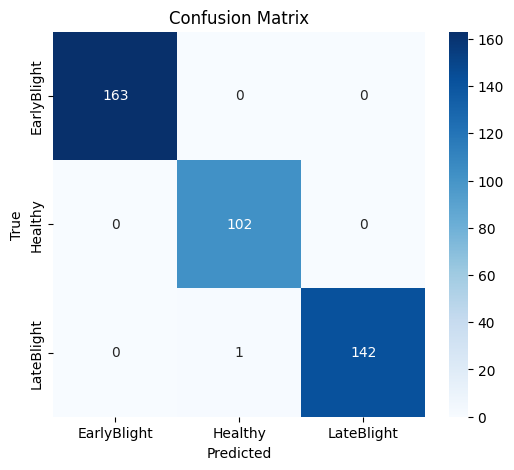

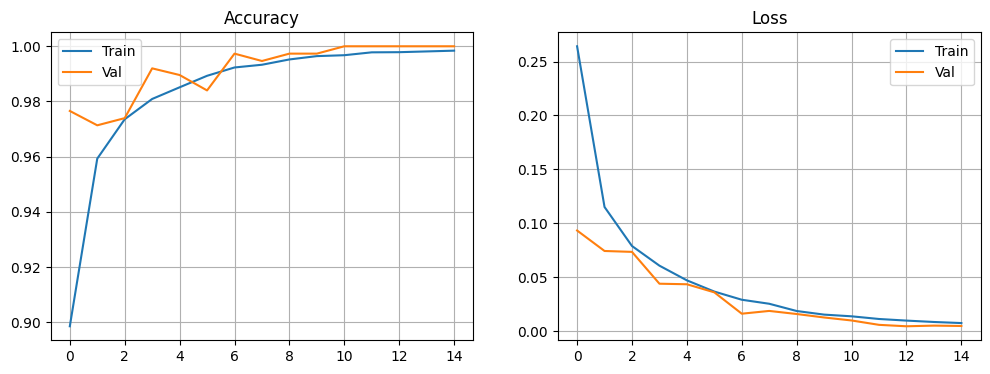

In [8]:
# ============================================================
# MOBILENETV1 PIPELINE (256x256) + FULL EVALUATION
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/pld-foldds/PLD_FOLDDATASET"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 256   # ✅ as requested
BATCH_SIZE = 32
EPOCHS = 15

# ---------------- LOAD DATA ----------------
def load_data(folder):
    paths, labels = [], []
    classes = sorted(os.listdir(folder))

    for idx, cls in enumerate(classes):
        for f in os.listdir(os.path.join(folder, cls)):
            paths.append(os.path.join(folder, cls, f))
            labels.append(idx)

    return np.array(paths), np.array(labels), classes

X_train, y_train, class_names = load_data(TRAIN_DIR)
X_val, y_val, _ = load_data(VAL_DIR)
X_test, y_test, _ = load_data(TEST_DIR)

NUM_CLASSES = len(class_names)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

# ---------------- GENERATOR ----------------
def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)

                img = preprocess_input(img.astype("float32"))
                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, NUM_CLASSES)

# ---------------- MODEL (MobileNetV1) ----------------
base = MobileNet(weights="imagenet",
                 include_top=False,
                 input_shape=(IMG_SIZE, IMG_SIZE, 3))

base.trainable = False  # freeze initially

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs=base.input, outputs=out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ---------------- TRAIN ----------------
history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_data=generator(X_val, y_val),
    validation_steps=len(X_val)//BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

# ---------------- TEST ----------------
y_true, y_pred = [], []
test_gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(test_gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ---------------- METRICS ----------------
acc = np.mean(y_true == y_pred)
print(f"\n✅ Test Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ---------------- TRAINING CURVES ----------------
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
SAVE_PATH = "/kaggle/working/mobilenet_model.h5"

model.save(SAVE_PATH)

print(f"✅ Model saved at: {SAVE_PATH}")

✅ Model saved at: /kaggle/working/mobilenet_model.h5


In [10]:
# ============================================================
# DOMAIN ADAPTATION + FINE-TUNING (MobileNetV1 VERSION)
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/potatoleafplantvillage/PlantVillageExtended/Test"
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10

# ---------------- LOAD MODEL ----------------
MODEL_PATH = "/kaggle/working/mobilenet_model.h5"   # ✅ your MobileNet model
model = load_model(MODEL_PATH)

# ---------------- CLASS ORDER ----------------
class_names = ["EarlyBlight", "Healthy", "LateBlight"]

# ============================================================
# ROBUST DATA LOADING (AUTO CLASS MATCHING)
# ============================================================

paths, labels = [], []

for cls in os.listdir(DATASET_DIR):

    cls_lower = cls.lower()

    if "early" in cls_lower:
        label = class_names.index("EarlyBlight")
    elif "late" in cls_lower:
        label = class_names.index("LateBlight")
    elif "healthy" in cls_lower:
        label = class_names.index("Healthy")
    else:
        print("Skipping:", cls)
        continue

    cls_dir = os.path.join(DATASET_DIR, cls)

    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.jpg','.png','.jpeg')):
            paths.append(os.path.join(cls_dir, f))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("✅ Total loaded samples:", len(paths))

if len(paths) == 0:
    raise ValueError("❌ No data loaded. Check dataset path.")

# ============================================================
# SPLIT (DOMAIN ADAPTATION)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    paths, labels,
    test_size=0.8,
    stratify=labels,
    random_state=42
)

print("Adaptation train:", len(X_train))
print("Test:", len(X_test))

# ============================================================
# DATA GENERATOR (MobileNet preprocessing)
# ============================================================

def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)
                    if np.random.rand() < 0.3:
                        img = cv2.convertScaleAbs(img, alpha=1.2, beta=30)
                    if np.random.rand() < 0.3:
                        img = cv2.GaussianBlur(img, (3,3), 0)

                # ✅ MobileNet preprocessing
                img = preprocess_input(img.astype("float32"))

                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, 3)

# ============================================================
# FINE-TUNING (SAFE FOR MOBILENET)
# ============================================================

# Unfreeze last few layers (MobileNet is lightweight)
for layer in model.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# TRAIN
# ============================================================

history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    epochs=EPOCHS,
    verbose=1
)

# ============================================================
# TEST
# ============================================================

y_true, y_pred = [], []
gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ============================================================
# RESULTS
# ============================================================

acc = np.mean(y_true == y_pred)
print(f"\n✅ Improved Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

✅ Total loaded samples: 2152
Adaptation train: 430
Test: 1722
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.5647 - loss: 5.7232
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.6243 - loss: 3.6356
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.6519 - loss: 2.3920
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.7661 - loss: 1.4733
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8354 - loss: 0.7925
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.8448 - loss: 0.5794
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.8362 - loss: 0.6147
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9478 - loss: 0.2138
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9386 - loss: 0.2550
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9406 - loss: 0.1930

✅ Improved Accuracy: 0.5772

📊 Classification Report:
              precision    re

In [14]:
# ============================================================
# FINAL DOMAIN ADAPTATION (MobileNetV1 - FULL EPOCH TRAINING)
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/potatoleafplantvillage/PlantVillageExtended/Test"  # ✅ FULL dataset
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10

# ---------------- LOAD MODEL ----------------
MODEL_PATH = "/kaggle/working/mobilenet_model.h5"
model = load_model(MODEL_PATH)

# ---------------- CLASS ORDER ----------------
class_names = ["EarlyBlight", "Healthy", "LateBlight"]

# ============================================================
# DATA LOADING
# ============================================================

paths, labels = [], []

for cls in os.listdir(DATASET_DIR):
    cls_lower = cls.lower()

    if "early" in cls_lower:
        label = 0
    elif "healthy" in cls_lower:
        label = 1
    elif "late" in cls_lower:
        label = 2
    else:
        continue

    cls_dir = os.path.join(DATASET_DIR, cls)

    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.jpg','.png','.jpeg')):
            paths.append(os.path.join(cls_dir, f))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("Total samples:", len(paths))

# ============================================================
# SPLIT (TRAIN / VAL / TEST)
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    paths, labels, test_size=0.3, stratify=labels, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

# ============================================================
# DATA GENERATOR
# ============================================================

def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)
                    if np.random.rand() < 0.3:
                        img = cv2.convertScaleAbs(img, alpha=1.3, beta=40)
                    if np.random.rand() < 0.3:
                        img = cv2.GaussianBlur(img, (5,5), 0)
                    if np.random.rand() < 0.3:
                        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

                img = preprocess_input(img.astype("float32"))

                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, 3)

# ============================================================
# FINE-TUNING
# ============================================================

for layer in model.layers[:-20]:
    layer.trainable = False

for layer in model.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# CALLBACKS (NO EARLY STOPPING)
# ============================================================

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_mobilenet.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================================
# TRAIN
# ============================================================

history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    validation_data=generator(X_val, y_val),
    validation_steps=max(1, len(X_val)//BATCH_SIZE),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# LOAD BEST MODEL
# ============================================================

model = load_model("/kaggle/working/best_mobilenet.h5")

# ============================================================
# TEST
# ============================================================

y_true, y_pred = [], []
gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ============================================================
# RESULTS
# ============================================================

acc = np.mean(y_true == y_pred)
print(f"\n✅ Final Test Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Total samples: 2152
Train: 1506 Val: 323 Test: 323
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5964 - loss: 4.1611
Epoch 1: val_accuracy improved from -inf to 0.50937, saving model to /kaggle/working/best_mobilenet.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 206ms/step - accuracy: 0.5972 - loss: 4.1415 - val_accuracy: 0.5094 - val_loss: 8.0990 - learning_rate: 1.0000e-05
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8183 - loss: 1.0107
Epoch 2: val_accuracy improved from 0.50937 to 0.54375, saving model to /kaggle/working/best_mobilenet.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 141ms/step - accuracy: 0.8188 - loss: 1.0068 - val_accuracy: 0.5437 - val_loss: 5.7175 - learning_rate: 1.0000e-05
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9003 - loss: 0.4313
Epoch 3: val_accuracy improved from 0.54375 to 0.59375, saving model to /kaggle/working/best_mobilenet.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 0.9004 - loss: 0.4309 - val_accuracy: 0.5938 - val_loss: 3.4519 - learning_rate: 1.0000e-05
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9209 - loss: 0.3035
Epoch 4: val_accuracy improved from 0.59375 to 0.68041, saving model to /kaggle/working/best_mobilenet.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 265ms/step - accuracy: 0.9209 - loss: 0.3032 - val_accuracy: 0.6804 - val_loss: 2.4142 - learning_rate: 1.0000e-05
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9200 - loss: 0.3309
Epoch 5: val_accuracy improved from 0.68041 to 0.76632, saving model to /kaggle/working/best_mobilenet.h5


...

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.9413 - loss: 0.1857 - val_accuracy: 0.8763 - val_loss: 0.4453 - learning_rate: 1.0000e-05
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9483 - loss: 0.1553
Epoch 8: val_accuracy improved from 0.87629 to 0.91753, saving model to /kaggle/working/best_mobilenet.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.9484 - loss: 0.1551 - val_accuracy: 0.9175 - val_loss: 0.3998 - learning_rate: 1.0000e-05
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9633 - loss: 0.1112
Epoch 9: val_accuracy improved from 0.91753 to 0.93471, saving model to /kaggle/working/best_mobilenet.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.9632 - loss: 0.1115 - val_accuracy: 0.9347 - val_loss: 0.2836 - learning_rate: 1.0000e-05
Epoch 10/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9597 - loss: 0.1457
Epoch 10: val_accuracy improved from 0.93471 to 0.95876, saving model to /kaggle/working/best_mobilenet.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.9598 - loss: 0.1453 - val_accuracy: 0.9588 - val_loss: 0.2030 - learning_rate: 1.0000e-05



✅ Final Test Accuracy: 0.9505

📊 Classification Report:
              precision    recall  f1-score   support

 EarlyBlight       1.00      0.93      0.96       150
     Healthy       0.95      0.83      0.88        23
  LateBlight       0.91      0.99      0.95       150

    accuracy                           0.95       323
   macro avg       0.95      0.92      0.93       323
weighted avg       0.95      0.95      0.95       323



In [17]:
from inception_v4 import InceptionV4

ModuleNotFoundError: No module named 'inception_v4'

Train: 18257 Val: 407 Test: 408
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_207 (Conv2D) │ (None, 127, 127,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 127, 127,  │         96 │ conv2d_207[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_203      │ (None, 127, 127,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_208 (Conv2D) │ (None, 125, 125,  │      9,216 │ activation_203[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │         96 │ conv2d_208[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_204      │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_209 (Conv2D) │ (None, 125, 125,  │     18,432 │ activation_204[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │        192 │ conv2d_209[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_205      │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 62, 62,    │          0 │ activation_205[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_210 (Conv2D) │ (None, 62, 62,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 62,    │        240 │ conv2d_210[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_206      │ (None, 62, 62,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_211 (Conv2D) │ (None, 60, 60,    │    138,240 │ activation_206[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        576 │ conv2d_211[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_207      │ (None, 60, 60,    │          0 │ batch_normalizat

 Total params: 22,853,411 (87.18 MB)

 Trainable params: 1,050,627 (4.01 MB)

...

570/570 ━━━━━━━━━━━━━━━━━━━━ 97s 157ms/step - accuracy: 0.9178 - loss: 0.2348 - val_accuracy: 0.9557 - val_loss: 0.1522
Epoch 3/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9331 - loss: 0.1818
Epoch 3: val_accuracy did not improve from 0.95573
570/570 ━━━━━━━━━━━━━━━━━━━━ 85s 150ms/step - accuracy: 0.9331 - loss: 0.1818 - val_accuracy: 0.9479 - val_loss: 0.1435
Epoch 4/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9446 - loss: 0.1549
Epoch 4: val_accuracy did not improve from 0.95573
570/570 ━━━━━━━━━━━━━━━━━━━━ 102s 179ms/step - accuracy: 0.9446 - loss: 0.1549 - val_accuracy: 0.9520 - val_loss: 0.1327
Epoch 5/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9545 - loss: 0.1342
Epoch 5: val_accuracy improved from 0.95573 to 0.97656, saving model to /kaggle/working/best_inceptionv3.h5


570/570 ━━━━━━━━━━━━━━━━━━━━ 85s 149ms/step - accuracy: 0.9545 - loss: 0.1342 - val_accuracy: 0.9766 - val_loss: 0.1060
Epoch 6/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9603 - loss: 0.1118
Epoch 6: val_accuracy did not improve from 0.97656
570/570 ━━━━━━━━━━━━━━━━━━━━ 88s 155ms/step - accuracy: 0.9603 - loss: 0.1118 - val_accuracy: 0.9733 - val_loss: 0.0851
Epoch 7/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9621 - loss: 0.1110
Epoch 7: val_accuracy did not improve from 0.97656
570/570 ━━━━━━━━━━━━━━━━━━━━ 84s 148ms/step - accuracy: 0.9621 - loss: 0.1110 - val_accuracy: 0.9653 - val_loss: 0.1001
Epoch 8/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9685 - loss: 0.0902
Epoch 8: val_accuracy did not improve from 0.97656
570/570 ━━━━━━━━━━━━━━━━━━━━ 94s 165ms/step - accuracy: 0.9685 - loss: 0.0902 - val_accuracy: 0.9573 - val_loss: 0.1135
Epoch 9/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9701 - loss: 0.0865
Epoch 9: val_ac

570/570 ━━━━━━━━━━━━━━━━━━━━ 84s 148ms/step - accuracy: 0.9701 - loss: 0.0865 - val_accuracy: 0.9840 - val_loss: 0.0599
Epoch 10/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9741 - loss: 0.0771
Epoch 10: val_accuracy did not improve from 0.98400
570/570 ━━━━━━━━━━━━━━━━━━━━ 83s 146ms/step - accuracy: 0.9741 - loss: 0.0771 - val_accuracy: 0.9787 - val_loss: 0.0670


✅ Final model saved



✅ Test Accuracy: 0.9657

📊 Classification Report:
              precision    recall  f1-score   support

 EarlyBlight       0.99      0.96      0.97       163
     Healthy       0.94      0.97      0.96       102
  LateBlight       0.96      0.97      0.97       143

    accuracy                           0.97       408
   macro avg       0.96      0.97      0.96       408
weighted avg       0.97      0.97      0.97       408



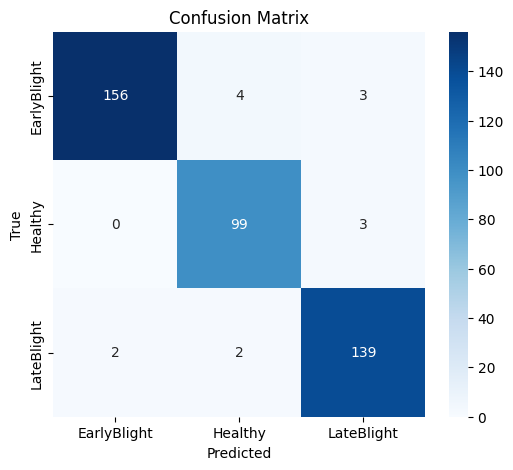

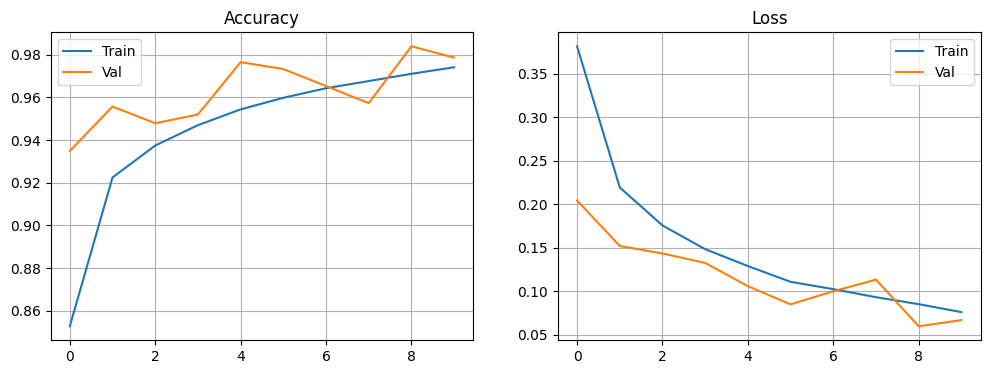

In [22]:
# ============================================================
# INCEPTIONV3 PIPELINE (256x256) + FULL EVALUATION + SAVE
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/pld-foldds/PLD_FOLDDATASET"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 256   # ✔ works fine
BATCH_SIZE = 32
EPOCHS = 10

# ---------------- LOAD DATA ----------------
def load_data(folder):
    paths, labels = [], []
    classes = sorted(os.listdir(folder))

    for idx, cls in enumerate(classes):
        for f in os.listdir(os.path.join(folder, cls)):
            paths.append(os.path.join(folder, cls, f))
            labels.append(idx)

    return np.array(paths), np.array(labels), classes

X_train, y_train, class_names = load_data(TRAIN_DIR)
X_val, y_val, _ = load_data(VAL_DIR)
X_test, y_test, _ = load_data(TEST_DIR)

NUM_CLASSES = len(class_names)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

# ---------------- GENERATOR ----------------
def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)

                img = preprocess_input(img.astype("float32"))
                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, NUM_CLASSES)

# ---------------- MODEL ----------------
base = InceptionV3(weights="imagenet",
                   include_top=False,
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))

base.trainable = False   # freeze first

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs=base.input, outputs=out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ---------------- CALLBACK ----------------
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_inceptionv3.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# ---------------- TRAIN ----------------
history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    validation_data=generator(X_val, y_val),
    validation_steps=max(1, len(X_val)//BATCH_SIZE),
    epochs=EPOCHS,
    callbacks=[checkpoint],
    verbose=1
)

# ---------------- SAVE FINAL ----------------
model.save("/kaggle/working/final_inceptionv3.h5")
print("✅ Final model saved")

# ---------------- LOAD BEST ----------------
model = tf.keras.models.load_model("/kaggle/working/best_inceptionv3.h5")

# ---------------- TEST ----------------
y_true, y_pred = [], []
test_gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(test_gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ---------------- METRICS ----------------
acc = np.mean(y_true == y_pred)
print(f"\n✅ Test Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ---------------- TRAINING CURVES ----------------
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [23]:
# ============================================================
# DOMAIN ADAPTATION + FINE-TUNING (INCEPTIONV3 VERSION)
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/potatoleafplantvillage/PlantVillageExtended/Test"
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10

# ---------------- CLASS ORDER ----------------
class_names = ["EarlyBlight", "Healthy", "LateBlight"]

# ============================================================
# DATA LOADING
# ============================================================

paths, labels = [], []

for cls in os.listdir(DATASET_DIR):
    cls_lower = cls.lower()

    if "early" in cls_lower:
        label = 0
    elif "healthy" in cls_lower:
        label = 1
    elif "late" in cls_lower:
        label = 2
    else:
        continue

    cls_dir = os.path.join(DATASET_DIR, cls)

    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.jpg','.png','.jpeg')):
            paths.append(os.path.join(cls_dir, f))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("Total samples:", len(paths))

# ============================================================
# SPLIT
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    paths, labels, test_size=0.3, stratify=labels, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

# ============================================================
# DATA GENERATOR
# ============================================================

def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)
                    if np.random.rand() < 0.3:
                        img = cv2.convertScaleAbs(img, alpha=1.3, beta=40)
                    if np.random.rand() < 0.3:
                        img = cv2.GaussianBlur(img, (5,5), 0)
                    if np.random.rand() < 0.3:
                        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

                img = preprocess_input(img.astype("float32"))

                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, 3)

# ============================================================
# MODEL (INCEPTIONV3)
# ============================================================

base = InceptionV3(weights="imagenet",
                   include_top=False,
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(3, activation="softmax")(x)

model = Model(inputs=base.input, outputs=outputs)

# ============================================================
# FINE-TUNING
# ============================================================

for layer in base.layers[:-30]:
    layer.trainable = False

for layer in base.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# CALLBACKS (NO EARLY STOPPING)
# ============================================================

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_inceptionv3.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================================
# TRAIN
# ============================================================

history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    validation_data=generator(X_val, y_val),
    validation_steps=max(1, len(X_val)//BATCH_SIZE),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# LOAD BEST MODEL
# ============================================================

model = tf.keras.models.load_model("/kaggle/working/best_inceptionv3.h5")

# ============================================================
# TEST
# ============================================================

y_true, y_pred = [], []
gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ============================================================
# RESULTS
# ============================================================

acc = np.mean(y_true == y_pred)
print(f"\n✅ Final Test Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Total samples: 2152
Train: 1506 Val: 323 Test: 323
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.4192 - loss: 1.0698
Epoch 1: val_accuracy improved from -inf to 0.81563, saving model to /kaggle/working/best_inceptionv3.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 39s 397ms/step - accuracy: 0.4219 - loss: 1.0662 - val_accuracy: 0.8156 - val_loss: 0.6036 - learning_rate: 1.0000e-05
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7604 - loss: 0.6317
Epoch 2: val_accuracy improved from 0.81563 to 0.86563, saving model to /kaggle/working/best_inceptionv3.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - accuracy: 0.7607 - loss: 0.6309 - val_accuracy: 0.8656 - val_loss: 0.4174 - learning_rate: 1.0000e-05
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8264 - loss: 0.4962
Epoch 3: val_accuracy improved from 0.86563 to 0.86875, saving model to /kaggle/working/best_inceptionv3.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - accuracy: 0.8264 - loss: 0.4958 - val_accuracy: 0.8687 - val_loss: 0.3751 - learning_rate: 1.0000e-05
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8769 - loss: 0.3867
Epoch 4: val_accuracy improved from 0.86875 to 0.91065, saving model to /kaggle/working/best_inceptionv3.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 319ms/step - accuracy: 0.8768 - loss: 0.3863 - val_accuracy: 0.9107 - val_loss: 0.2896 - learning_rate: 1.0000e-05
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8697 - loss: 0.3500
Epoch 5: val_accuracy improved from 0.91065 to 0.91753, saving model to /kaggle/working/best_inceptionv3.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - accuracy: 0.8696 - loss: 0.3502 - val_accuracy: 0.9175 - val_loss: 0.2870 - learning_rate: 1.0000e-05
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8816 - loss: 0.3149
Epoch 6: val_accuracy improved from 0.91753 to 0.93471, saving model to /kaggle/working/best_inceptionv3.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.8818 - loss: 0.3145 - val_accuracy: 0.9347 - val_loss: 0.2630 - learning_rate: 1.0000e-05
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9015 - loss: 0.2668
Epoch 7: val_accuracy improved from 0.93471 to 0.96220, saving model to /kaggle/working/best_inceptionv3.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.9015 - loss: 0.2669 - val_accuracy: 0.9622 - val_loss: 0.2011 - learning_rate: 1.0000e-05
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9167 - loss: 0.2491
Epoch 8: val_accuracy did not improve from 0.96220
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.9167 - loss: 0.2491 - val_accuracy: 0.9485 - val_loss: 0.2363 - learning_rate: 1.0000e-05
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9256 - loss: 0.2298
Epoch 9: val_accuracy did not improve from 0.96220

Epoch 9: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.9256 - loss: 0.2301 - val_accuracy: 0.9485 - val_loss: 0.2066 - learning_rate: 1.0000e-05
Epoch 10/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9266 - loss: 0.2241
Epoch 10: val_accuracy did not improve from 0.96220
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.9265 - loss: 0.2241 -


✅ Final Test Accuracy: 0.9319

📊 Classification Report:
              precision    recall  f1-score   support

 EarlyBlight       0.95      0.98      0.96       150
     Healthy       0.88      0.61      0.72        23
  LateBlight       0.92      0.93      0.93       150

    accuracy                           0.93       323
   macro avg       0.91      0.84      0.87       323
weighted avg       0.93      0.93      0.93       323



2026-05-03 18:06:55.201088: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777831615.380300      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777831615.433227      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777831615.854714      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777831615.854755      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777831615.854758      57 computation_placer.cc:177] computation placer alr

Train: 18257 Val: 407 Test: 408


I0000 00:00:1777831629.544833      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

...

570/570 ━━━━━━━━━━━━━━━━━━━━ 266s 409ms/step - accuracy: 0.8604 - loss: 0.6472 - val_accuracy: 0.9922 - val_loss: 0.3767 - learning_rate: 3.9093e-05
Epoch 2/10


2026-05-03 18:11:46.347818: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 18:11:46.557348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 18:11:46.831810: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 18:11:47.040983: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9592 - loss: 0.4405
Epoch 2: val_accuracy did not improve from 0.99219
570/570 ━━━━━━━━━━━━━━━━━━━━ 95s 137ms/step - accuracy: 0.9592 - loss: 0.4405 - val_accuracy: 0.9922 - val_loss: 0.3703 - learning_rate: 0.0000e+00
Epoch 3/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9613 - loss: 0.4369
Epoch 3: val_accuracy did not improve from 0.99219
570/570 ━━━━━━━━━━━━━━━━━━━━ 73s 129ms/step - accuracy: 0.9613 - loss: 0.4369 - val_accuracy: 0.9922 - val_loss: 0.3691 - learning_rate: 0.0000e+00
Epoch 4/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9558 - loss: 0.4412
Epoch 4: val_accuracy improved from 0.99219 to 0.99733, saving model to /kaggle/working/best_efficientnetb0.h5


570/570 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.9558 - loss: 0.4412 - val_accuracy: 0.9973 - val_loss: 0.3672 - learning_rate: 0.0000e+00
Epoch 5/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9598 - loss: 0.4403
Epoch 5: val_accuracy did not improve from 0.99733
570/570 ━━━━━━━━━━━━━━━━━━━━ 75s 132ms/step - accuracy: 0.9598 - loss: 0.4403 - val_accuracy: 0.9948 - val_loss: 0.3678 - learning_rate: 0.0000e+00
Epoch 6/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9615 - loss: 0.4374
Epoch 6: val_accuracy did not improve from 0.99733
570/570 ━━━━━━━━━━━━━━━━━━━━ 78s 137ms/step - accuracy: 0.9615 - loss: 0.4374 - val_accuracy: 0.9947 - val_loss: 0.3697 - learning_rate: 0.0000e+00
Epoch 7/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9622 - loss: 0.4361
Epoch 7: val_accuracy did not improve from 0.99733
570/570 ━━━━━━━━━━━━━━━━━━━━ 76s 134ms/step - accuracy: 0.9622 - loss: 0.4361 - val_accuracy: 0.9947 - val_loss: 0.3681 - learning_rate: 0.


✅ Test Accuracy: 0.9951

📊 Classification Report:
              precision    recall  f1-score   support

 EarlyBlight       1.00      0.99      0.99       163
     Healthy       0.98      1.00      0.99       102
  LateBlight       1.00      1.00      1.00       143

    accuracy                           1.00       408
   macro avg       0.99      1.00      0.99       408
weighted avg       1.00      1.00      1.00       408



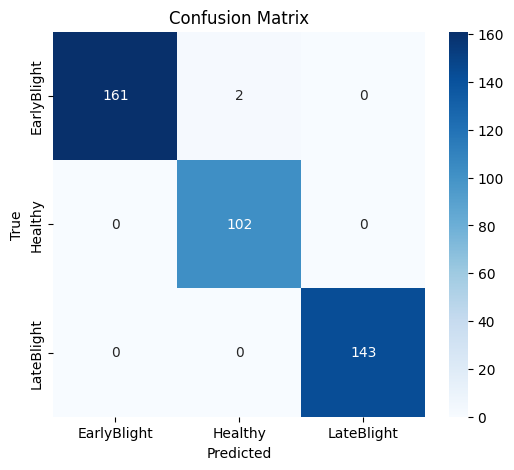

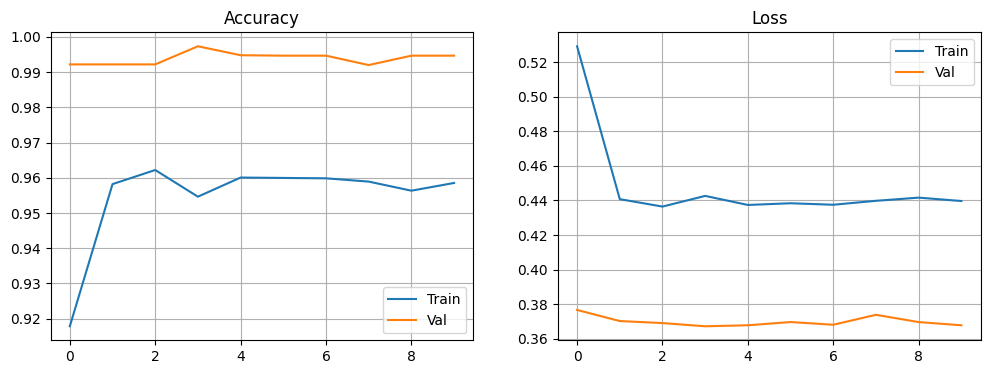

In [1]:
# ============================================================
# EFFICIENTNETB0 PIPELINE (256x256) + FULL EVALUATION + OPTIMIZED
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/pld-foldds/PLD_FOLDDATASET"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 256   # EfficientNet default is 224, but 256 works well
BATCH_SIZE = 32
EPOCHS = 10

# ---------------- LOAD DATA ----------------
def load_data(folder):
    paths, labels = [], []
    classes = sorted(os.listdir(folder))

    for idx, cls in enumerate(classes):
        for f in os.listdir(os.path.join(folder, cls)):
            paths.append(os.path.join(folder, cls, f))
            labels.append(idx)

    return np.array(paths), np.array(labels), classes

X_train, y_train, class_names = load_data(TRAIN_DIR)
X_val, y_val, _ = load_data(VAL_DIR)
X_test, y_test, _ = load_data(TEST_DIR)

NUM_CLASSES = len(class_names)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

# ============================================================
# STRONG GENERATOR
# ============================================================

def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)
                    if np.random.rand() < 0.4:
                        img = cv2.convertScaleAbs(img, alpha=1.4, beta=40)
                    if np.random.rand() < 0.3:
                        img = cv2.GaussianBlur(img, (5,5), 0)
                    if np.random.rand() < 0.3:
                        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

                img = preprocess_input(img.astype("float32"))

                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, NUM_CLASSES)

# ============================================================
# MODEL (EfficientNetB0)
# ============================================================

base = EfficientNetB0(weights="imagenet",
                      include_top=False,
                      input_shape=(IMG_SIZE, IMG_SIZE, 3))

base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)  # 🔥 improves stability
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs=base.input, outputs=out)

# ============================================================
# FINE-TUNING
# ============================================================

for layer in base.layers[:-40]:
    layer.trainable = False

for layer in base.layers[-40:]:
    layer.trainable = True

# ============================================================
# LR + LOSS
# ============================================================

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=1000
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# CALLBACKS
# ============================================================

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_efficientnetb0.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

callbacks = [
    checkpoint,
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================================
# TRAIN
# ============================================================

history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    validation_data=generator(X_val, y_val),
    validation_steps=max(1, len(X_val)//BATCH_SIZE),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# SAVE FINAL MODEL
# ============================================================

model.save("/kaggle/working/final_efficientnetb0.h5")

# ============================================================
# LOAD BEST MODEL
# ============================================================

model = tf.keras.models.load_model("/kaggle/working/best_efficientnetb0.h5")

# ============================================================
# TEST
# ============================================================

y_true, y_pred = [], []
test_gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(test_gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ============================================================
# RESULTS
# ============================================================

acc = np.mean(y_true == y_pred)
print(f"\n✅ Test Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ============================================================
# TRAINING CURVES
# ============================================================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
# ============================================================
# FINAL PIPELINE: BASELINE + DOMAIN ADAPTATION (EFFICIENTNETB0)
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/potatoleafplantvillage/PlantVillageExtended/Test"
MODEL_PATH = "/kaggle/working/final_efficientnetb0.h5"   # trained on Dataset A

IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10

class_names = ["EarlyBlight", "Healthy", "LateBlight"]

# ============================================================
# LOAD DATASET B
# ============================================================

paths, labels = [], []

for cls in os.listdir(DATASET_DIR):
    cls_lower = cls.lower()

    if "early" in cls_lower:
        label = 0
    elif "healthy" in cls_lower:
        label = 1
    elif "late" in cls_lower:
        label = 2
    else:
        continue

    cls_dir = os.path.join(DATASET_DIR, cls)

    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.jpg','.png','.jpeg')):
            paths.append(os.path.join(cls_dir, f))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("Total samples:", len(paths))

# ============================================================
# SPLIT (LEAKAGE-FREE)
# ============================================================

# 70% TEST (UNSEEN)
X_temp, X_test, y_temp, y_test = train_test_split(
    paths, labels, test_size=0.7, stratify=labels, random_state=42
)

# Remaining → train + val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.33, stratify=y_temp, random_state=42
)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

# ============================================================
# DATA GENERATOR (FIXED)
# ============================================================

class DataGenerator(tf.keras.utils.Sequence):

    def __init__(self, paths, labels, batch_size, augment=False, shuffle=True):
        self.paths = paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.indexes = np.arange(len(paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]

        imgs, labs = [], []

        for j in batch_idx:
            img = cv2.imread(self.paths[j])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            if self.augment:
                if np.random.rand() < 0.5:
                    img = cv2.flip(img, 1)
                if np.random.rand() < 0.4:
                    img = cv2.convertScaleAbs(img, alpha=1.3, beta=40)
                if np.random.rand() < 0.3:
                    img = cv2.GaussianBlur(img, (5,5), 0)

            img = preprocess_input(img.astype("float32"))

            imgs.append(img)
            labs.append(self.labels[j])

        return np.array(imgs), tf.keras.utils.to_categorical(labs, 3)

# Generators
train_gen = DataGenerator(X_train, y_train, BATCH_SIZE, augment=True)
val_gen   = DataGenerator(X_val, y_val, BATCH_SIZE, augment=False)
test_gen  = DataGenerator(X_test, y_test, BATCH_SIZE, augment=False, shuffle=False)

# ============================================================
# 🧪 BASELINE TEST (A → B)
# ============================================================

print("\n🔵 Running BASELINE (no fine-tuning)...")

model = load_model(MODEL_PATH)

preds = model.predict(test_gen, verbose=0)
y_pred = np.argmax(preds, axis=1)
y_true = y_test

baseline_acc = np.mean(y_true == y_pred)

print(f"\n📊 Baseline Accuracy (A → B): {baseline_acc:.4f}")
print(classification_report(y_true, y_pred, target_names=class_names))

# ============================================================
# 🔧 DOMAIN ADAPTATION
# ============================================================

print("\n🟢 Running DOMAIN ADAPTATION...")

# Reload original model again
model = load_model(MODEL_PATH)

# Fine-tuning
for layer in model.layers[:-40]:
    layer.trainable = False

for layer in model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_adapted_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

# Train
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# 🧪 TEST AFTER ADAPTATION
# ============================================================

model = load_model("/kaggle/working/best_adapted_model.keras")

preds = model.predict(test_gen, verbose=0)
y_pred = np.argmax(preds, axis=1)

adapt_acc = np.mean(y_true == y_pred)

print(f"\n📊 Adapted Accuracy (A → B): {adapt_acc:.4f}")
print(classification_report(y_true, y_pred, target_names=class_names))

# ============================================================
# 📊 CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.title("Confusion Matrix (After Adaptation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Total samples: 2152
Train: 432 Val: 213 Test: 1507

🔵 Running BASELINE (no fine-tuning)...


ValueError: No model config found in the file at /kaggle/working/final_efficientnetb0.h5.